# Experiment 3: Heart Disease Classification
## Using Decision Tree and Random Forest Classifiers

This notebook implements classification models to predict heart disease using the UCI Heart Disease dataset.

## 1. Import Required Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('archive/heart.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("First 5 rows:")
print(df.head())
print("\n" + "="*50)
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Statistical Summary:")
print(df.describe())

Dataset Shape: (1025, 14)

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Target Variable Distribution:")
print(df['target'].value_counts())
print("\n" + "="*50)
print("Target Variable Percentage:")
print(df['target'].value_counts(normalize=True) * 100)

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target Variable Distribution:
target
1    526
0    499
Name: count, dtype: int64

Target Variable Percentage:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


### Visualize Target Distribution

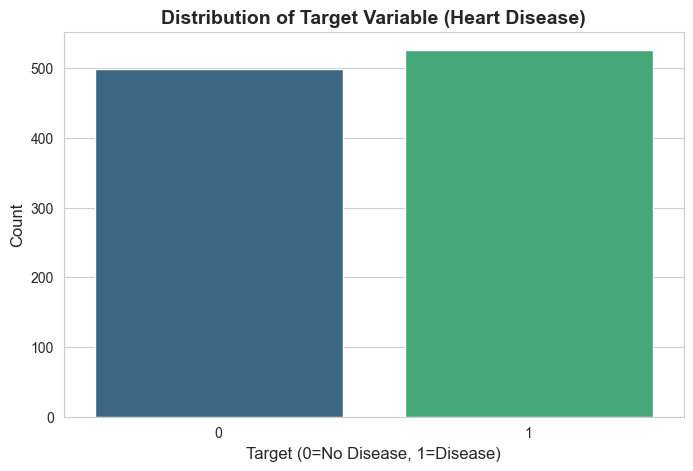

In [4]:
# Visualize target distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Target Variable (Heart Disease)', fontsize=14, fontweight='bold')
plt.xlabel('Target (0=No Disease, 1=Disease)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Correlation Heatmap

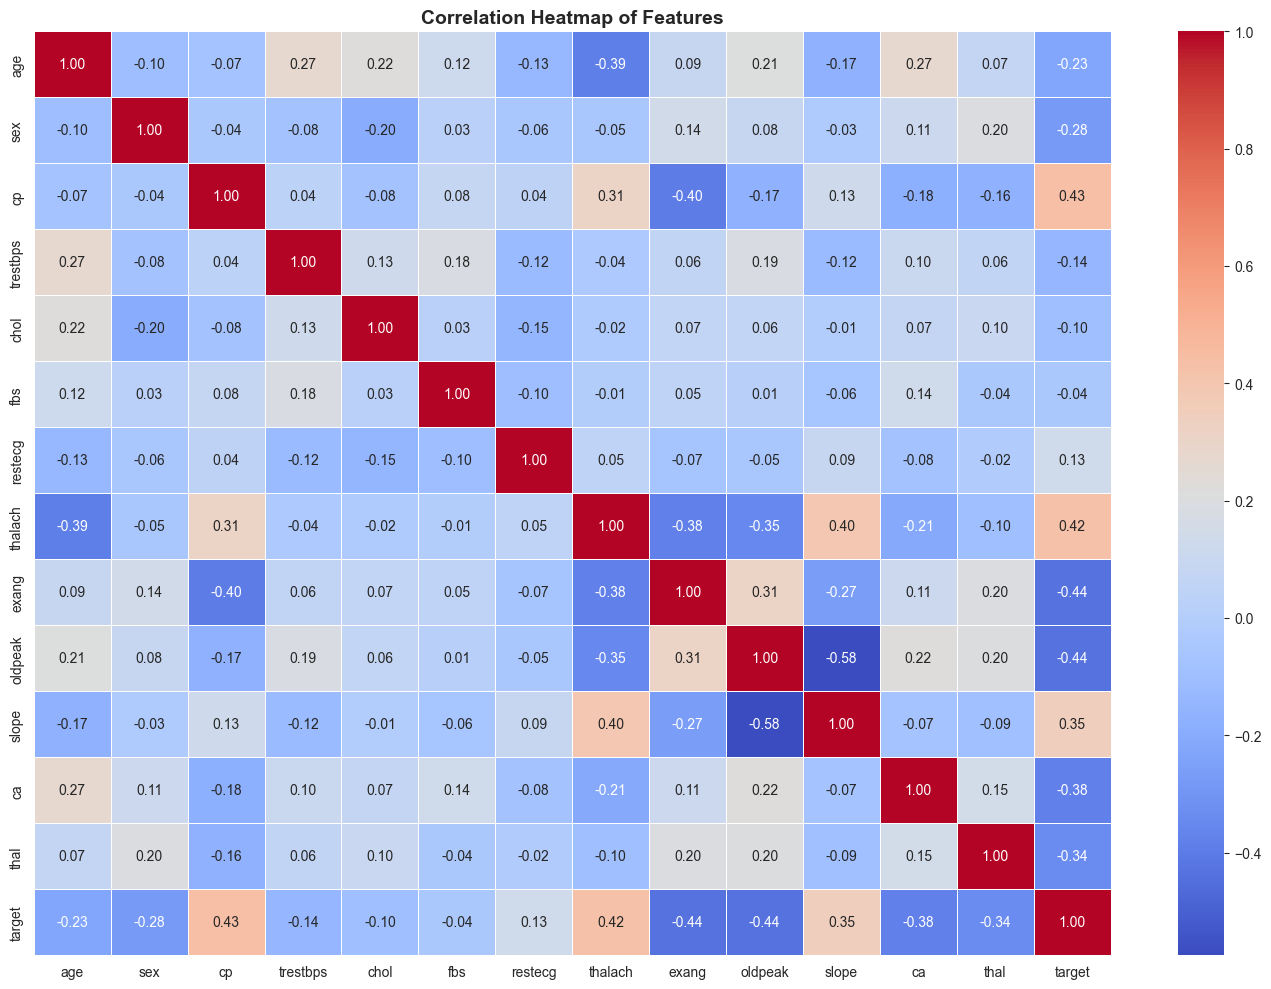

Features most correlated with target:
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


In [5]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Display features most correlated with target
print("Features most correlated with target:")
print(correlation_matrix['target'].sort_values(ascending=False))

## 3. Data Preprocessing and Feature Engineering

In [6]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features Shape: (1025, 13)
Target Shape: (1025,)

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 4. Split Data into Training and Testing Sets

In [7]:
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training set size: (820, 13)
Testing set size: (205, 13)

Training target distribution:
target
1    421
0    399
Name: count, dtype: int64

Testing target distribution:
target
1    105
0    100
Name: count, dtype: int64


## 5. Build and Train Model 1: Decision Tree Classifier

In [8]:
# Initialize and train Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")
print("Tree depth:", dt_classifier.get_depth())
print("Number of leaves:", dt_classifier.get_n_leaves())

Decision Tree Classifier trained successfully!
Tree depth: 5
Number of leaves: 24


In [9]:
# Make predictions with Decision Tree
y_pred_dt = dt_classifier.predict(X_test)

# Calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")

Decision Tree Accuracy: 0.8732 (87.32%)


### Decision Tree - Confusion Matrix

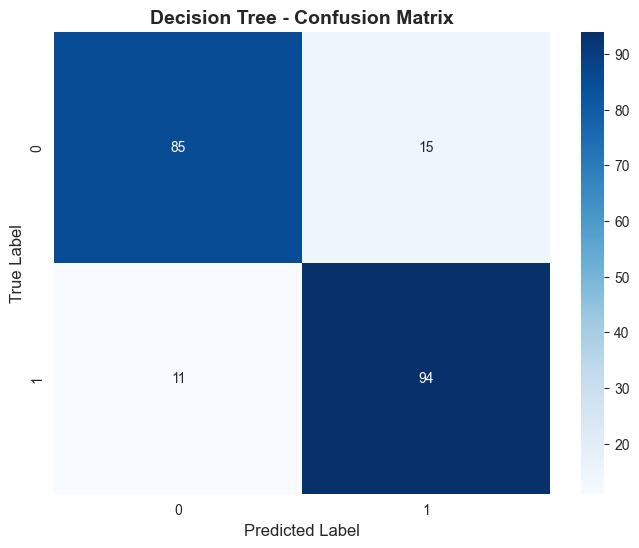

Confusion Matrix:
[[85 15]
 [11 94]]


In [10]:
# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Decision Tree - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

print("Confusion Matrix:")
print(cm_dt)

### Decision Tree - Classification Report

In [11]:
# Classification Report for Decision Tree
print("Decision Tree - Classification Report:")
print("="*50)
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))

Decision Tree - Classification Report:
              precision    recall  f1-score   support

  No Disease       0.89      0.85      0.87       100
     Disease       0.86      0.90      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205



### Visualize Decision Tree

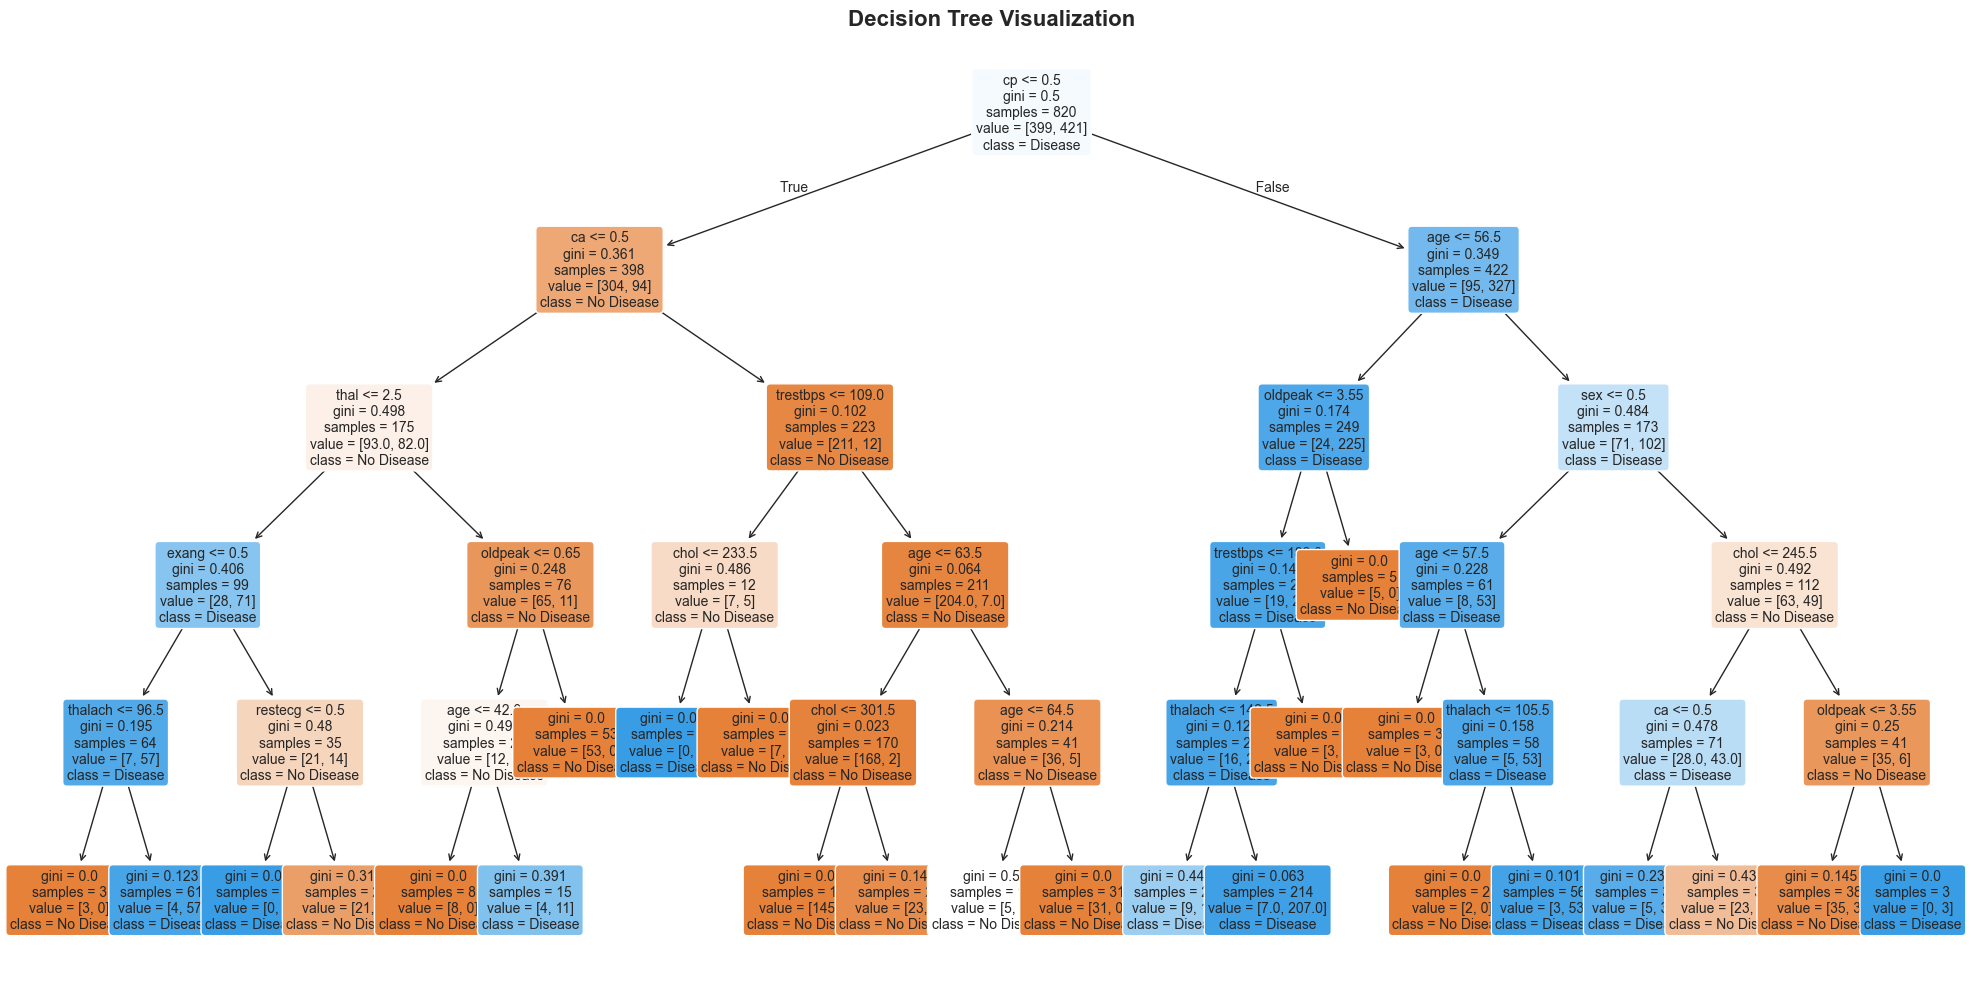

In [12]:
# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, 
          feature_names=X.columns, 
          class_names=['No Disease', 'Disease'],
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Build and Train Model 2: Random Forest Classifier

In [13]:
# Initialize and train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")
print("Number of trees:", rf_classifier.n_estimators)

Random Forest Classifier trained successfully!
Number of trees: 100


In [14]:
# Make predictions with Random Forest
y_pred_rf = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

Random Forest Accuracy: 0.9268 (92.68%)


### Random Forest - Confusion Matrix

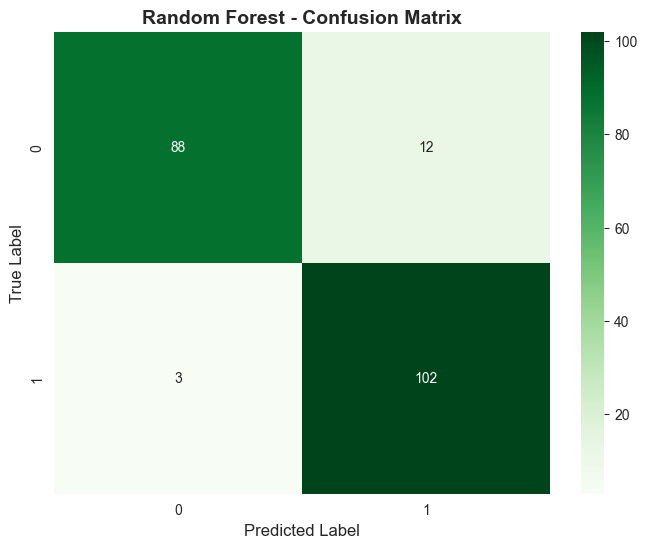

Confusion Matrix:
[[ 88  12]
 [  3 102]]


In [15]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=True)
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

print("Confusion Matrix:")
print(cm_rf)

### Random Forest - Classification Report

In [16]:
# Classification Report for Random Forest
print("Random Forest - Classification Report:")
print("="*50)
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))

Random Forest - Classification Report:
              precision    recall  f1-score   support

  No Disease       0.97      0.88      0.92       100
     Disease       0.89      0.97      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



## 7. Visualize Results - Feature Importance

Feature Importance (Random Forest):
     Feature  Importance
2         cp    0.186490
11        ca    0.130705
12      thal    0.117188
9    oldpeak    0.106199
7    thalach    0.103327
8      exang    0.099770
0        age    0.073805
10     slope    0.052800
3   trestbps    0.048294
4       chol    0.036874
1        sex    0.027912
6    restecg    0.010023
5        fbs    0.006614


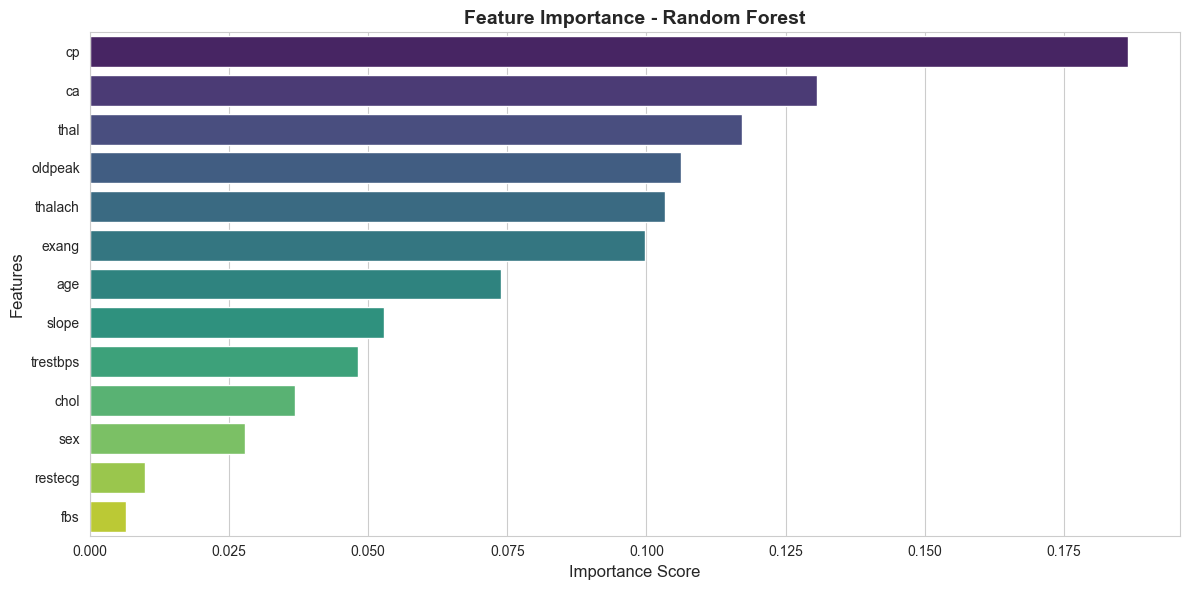

In [17]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Model Comparison


Model Comparison:
           Model  Accuracy
0  Decision Tree  0.873171
1  Random Forest  0.926829


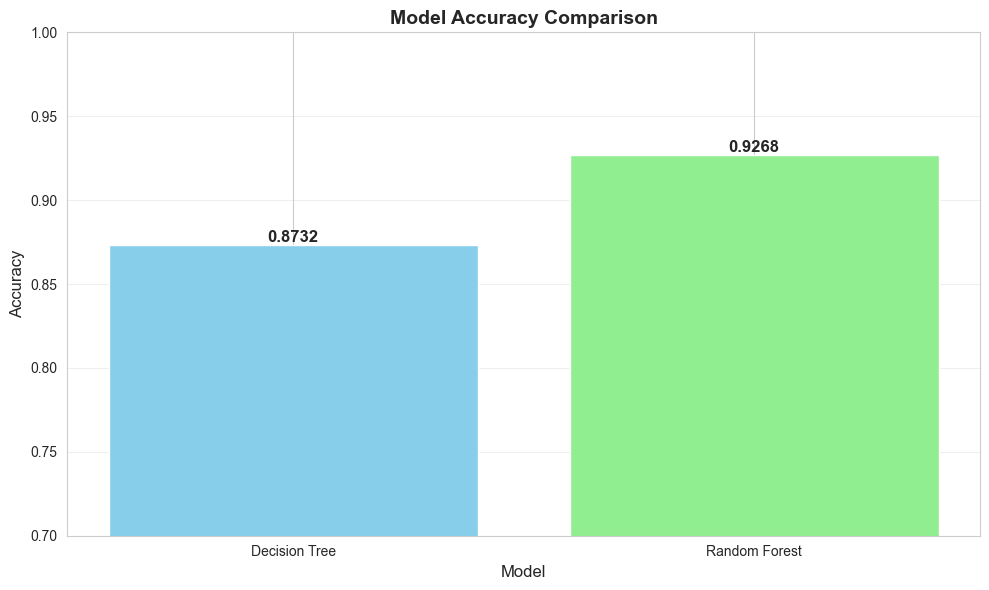


Best Performing Model: Random Forest


In [18]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_dt, accuracy_rf]
})

print("\nModel Comparison:")
print("="*50)
print(comparison_df)

# Visualize model comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy'], color=['skyblue', 'lightgreen'])
plt.ylim(0.7, 1.0)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Determine best model
best_model = 'Decision Tree' if accuracy_dt > accuracy_rf else 'Random Forest'
print(f"\nBest Performing Model: {best_model}")

## 9. Make Predictions on New Data

In [19]:
# Sample prediction on new data
# Using the first 3 samples from test set as an example
sample_data = X_test.iloc[:3]

print("Sample Data for Prediction:")
print(sample_data)
print("\n" + "="*50)

# Predict using both models
dt_prediction = dt_classifier.predict(sample_data)
rf_prediction = rf_classifier.predict(sample_data)

# Display predictions
prediction_results = pd.DataFrame({
    'Actual': y_test.iloc[:3].values,
    'Decision Tree Prediction': dt_prediction,
    'Random Forest Prediction': rf_prediction
})

print("\nPrediction Results:")
print(prediction_results)
print("\n" + "="*50)

# Interpret results
for i in range(len(prediction_results)):
    actual = "Disease" if prediction_results.iloc[i]['Actual'] == 1 else "No Disease"
    dt_pred = "Disease" if prediction_results.iloc[i]['Decision Tree Prediction'] == 1 else "No Disease"
    rf_pred = "Disease" if prediction_results.iloc[i]['Random Forest Prediction'] == 1 else "No Disease"
    
    print(f"Sample {i+1}:")
    print(f"  Actual: {actual}")
    print(f"  Decision Tree: {dt_pred}")
    print(f"  Random Forest: {rf_pred}")
    print()

Sample Data for Prediction:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
756   64    1   0       120   246    0        0       96      1      2.2   
353   57    1   0       110   201    0        1      126      1      1.5   
929   60    1   0       130   206    0        0      132      1      2.4   

     slope  ca  thal  
756      0   1     2  
353      1   0     1  
929      1   2     3  


Prediction Results:
   Actual  Decision Tree Prediction  Random Forest Prediction
0       0                         0                         0
1       1                         0                         0
2       0                         0                         0

Sample 1:
  Actual: No Disease
  Decision Tree: No Disease
  Random Forest: No Disease

Sample 2:
  Actual: Disease
  Decision Tree: No Disease
  Random Forest: No Disease

Sample 3:
  Actual: No Disease
  Decision Tree: No Disease
  Random Forest: No Disease



## 10. Save the Trained Models

In [20]:
import pickle

# Save Decision Tree model
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(dt_classifier, f)
print("Decision Tree model saved as 'decision_tree_model.pkl'")

# Save Random Forest model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)
print("Random Forest model saved as 'random_forest_model.pkl'")

print("\nBoth models saved successfully!")

Decision Tree model saved as 'decision_tree_model.pkl'
Random Forest model saved as 'random_forest_model.pkl'

Both models saved successfully!


## Conclusion

In this experiment, we successfully implemented and compared two classification algorithms:

1. **Decision Tree Classifier**: A simple, interpretable model that creates a tree-like structure of decisions.
2. **Random Forest Classifier**: An ensemble method that combines multiple decision trees to improve accuracy and reduce overfitting.

### Key Findings:
- Both models were trained on the UCI Heart Disease dataset
- Performance metrics including accuracy, precision, recall, and F1-score were evaluated
- Feature importance analysis revealed the most significant predictors of heart disease
- The models can be used to predict heart disease risk based on patient medical data

### Next Steps:
- Hyperparameter tuning to optimize model performance
- Cross-validation for more robust evaluation
- Try other ensemble methods like Gradient Boosting or XGBoost
- Deploy the model for real-time predictions